In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('preprocessed_dataset.csv')
df

,Viability,Smiles
0,113.28,CC(c1n[nH]c(-c2ccccc2)c1)N(C)C(C1=CC(C)=C(C)NC...
1,96.62,CCC1=NOC(CNS(c2cc(C(NCC=C)=O)ccc2)(=O)=O)C1
2,72.72,CN(CC1)C2(CCNCC2)CN1C(c1coc(CN2CCOCC2)c1)=O
3,104.81,CN(C)C(N1Cc2cc(CNC(c(scc3)c3N)=O)nn2CCC1)=O
4,103.84,Cc1c(CC(N(Cc2cc(O)ccc2)C2CC2)=O)c2c(C)ccc(C)c2...
...,...,...
24335,89.11,CC(C=C(C)N1)=C(C(N(CC2)CCN2c2nc(cccc3)c3s2)=O)...
24336,119.67,Cn1c(CNC(C(CC2)CN(CCCN(CCC3)C3=O)C2=O)=O)ncc1
24337,160.09,Cc(cc(CNC(CC1COCC1)=O)cc1)c1F
24338,125.00,Cc1cccc(OCCN(CCC2)CC2c2ccnn2CC(O)=O)c1C


In [3]:
import numpy as np 
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [12]:
def lipinski(smiles):

    rows = []

    for smi in smiles:

        mol = Chem.MolFromSmiles(str(smi))

        if mol is None:
            rows.append([np.nan, np.nan, np.nan, np.nan])
            continue

        rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol)
        ])

    return pd.DataFrame(
        rows,
        columns=["MW", "LogP", "NumHDonors", "NumHAcceptors"]
    )

In [8]:
df.dtypes

Viability    float64
Smiles        object
dtype: object

In [ ]:
#There are some invalid molecules, I tried with the excel file and csv file and same
#I'll change the function of the lipinski descriptors to omit them 

In [ ]:
#It seems there are some invalid molecules
for i, smi in enumerate(df.Smiles):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(i, smi)

118 C[C@H]1O[C@@H](C)CN(C[C@H]2[C@@H](CO)CN(Cc(cc3)ccc3C
911 CC(C)(CN(Cc1cc(C
2352 CCN(CCn1nccc1)C(c1ccc(C
5692 CC(C)(C
5750 CN(C)[C@@H](CN(Cc1ccc(C
5943 O=C(c1ccco1)N(C1)C[C@@H]2[C@H]1[C@H]2CN(CC
6536 CN(CC1(CCN(Cc2cc(C
7251 CCN(CC1(CCN(Cc(cc2)ccc2C
9781 CC(C)[C@@](C1)([C@@H](C)CN1C(c1ccc(C
9877 C=CCN1C(SCC
11394 N[C@@H]1[C@@H]2CN(Cc(cc3)ccc3C
17007 CCOc1cccc(OCC
17009 CCN1CCN(CC
17108 Clc(cccc1OCC
17293 Cc1cccc(OCC
18575 Cc(c(C(C1)c2cc(OCC
18876 COc1cccc(N(CC(N23)=NN(CC
19292 Cc(c(C(C1)c(cc2)ccc2OCC
21019 Cc(c(C(C1)c(cc2)cc(OC)c2OCC
22550 CC(C)n1ncc(C(C2)c(cc3)ccc3OCC
22733 CC(C)(C)n1ncc(C(C2)c3cc(OCC
24230 CC(c1nocc1)N(C)C(c(cc1)ccc1C


In [13]:
lipinski = lipinski(df.Smiles)
df_lipinski = pd.concat([df, lipinski], axis = 1)
df_lipinski
#

,Viability,Smiles,MW,LogP,NumHDonors,NumHAcceptors
0,113.28,CC(c1n[nH]c(-c2ccccc2)c1)N(C)C(C1=CC(C)=C(C)NC...,350.422,3.21504,2.0,3.0
1,96.62,CCC1=NOC(CNS(c2cc(C(NCC=C)=O)ccc2)(=O)=O)C1,351.428,1.43560,2.0,5.0
2,72.72,CN(CC1)C2(CCNCC2)CN1C(c1coc(CN2CCOCC2)c1)=O,362.474,0.62160,1.0,6.0
3,104.81,CN(C)C(N1Cc2cc(CNC(c(scc3)c3N)=O)nn2CCC1)=O,362.459,1.34410,2.0,5.0
4,103.84,Cc1c(CC(N(Cc2cc(O)ccc2)C2CC2)=O)c2c(C)ccc(C)c2...,362.473,4.53246,2.0,2.0
...,...,...,...,...,...,...
24335,89.11,CC(C=C(C)N1)=C(C(N(CC2)CCN2c2nc(cccc3)c3s2)=O)...,368.462,2.56384,1.0,5.0
24336,119.67,Cn1c(CNC(C(CC2)CN(CCCN(CCC3)C3=O)C2=O)=O)ncc1,361.446,0.28740,1.0,4.0
24337,160.09,Cc(cc(CNC(CC1COCC1)=O)cc1)c1F,251.301,2.17692,1.0,2.0
24338,125.00,Cc1cccc(OCCN(CCC2)CC2c2ccnn2CC(O)=O)c1C,357.454,2.84294,1.0,4.0


In [14]:
df_lipinski.isna().sum()

Viability         0
Smiles            0
MW               22
LogP             22
NumHDonors       22
NumHAcceptors    22
dtype: int64

In [17]:
#all na are the same
df_notna = df_lipinski[df_lipinski.MW.notna()]
df_notna

,Viability,Smiles,MW,LogP,NumHDonors,NumHAcceptors
0,113.28,CC(c1n[nH]c(-c2ccccc2)c1)N(C)C(C1=CC(C)=C(C)NC...,350.422,3.21504,2.0,3.0
1,96.62,CCC1=NOC(CNS(c2cc(C(NCC=C)=O)ccc2)(=O)=O)C1,351.428,1.43560,2.0,5.0
2,72.72,CN(CC1)C2(CCNCC2)CN1C(c1coc(CN2CCOCC2)c1)=O,362.474,0.62160,1.0,6.0
3,104.81,CN(C)C(N1Cc2cc(CNC(c(scc3)c3N)=O)nn2CCC1)=O,362.459,1.34410,2.0,5.0
4,103.84,Cc1c(CC(N(Cc2cc(O)ccc2)C2CC2)=O)c2c(C)ccc(C)c2...,362.473,4.53246,2.0,2.0
...,...,...,...,...,...,...
24335,89.11,CC(C=C(C)N1)=C(C(N(CC2)CCN2c2nc(cccc3)c3s2)=O)...,368.462,2.56384,1.0,5.0
24336,119.67,Cn1c(CNC(C(CC2)CN(CCCN(CCC3)C3=O)C2=O)=O)ncc1,361.446,0.28740,1.0,4.0
24337,160.09,Cc(cc(CNC(CC1COCC1)=O)cc1)c1F,251.301,2.17692,1.0,2.0
24338,125.00,Cc1cccc(OCCN(CCC2)CC2c2ccnn2CC(O)=O)c1C,357.454,2.84294,1.0,4.0


In [18]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Cytotoxicity dataset')

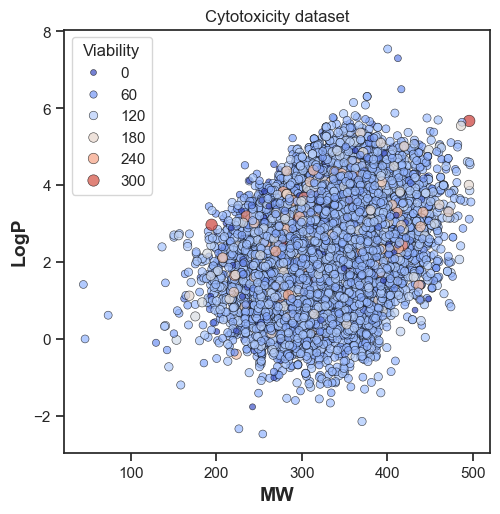

In [19]:
#Scatter plot of MW versus LogP
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_notna, hue='Viability', size='Viability', edgecolor='black', alpha=0.7, palette='coolwarm')

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.title('Cytotoxicity dataset')

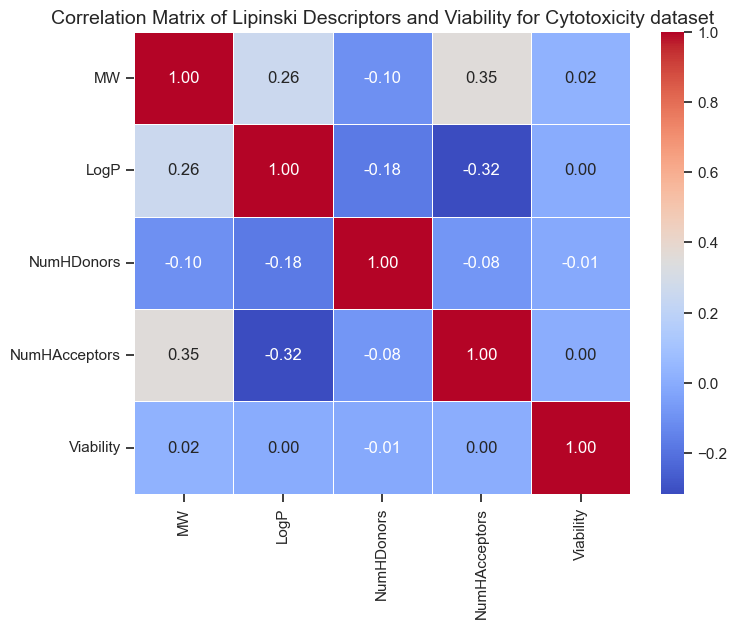

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for the correlation matrix
correlation_data = df_notna[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'Viability']]

# Calculate the correlation matrix
corr_matrix = correlation_data.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Lipinski Descriptors and Viability for Cytotoxicity dataset', fontsize=14)
plt.show()

In [23]:
#Statistical analysis
#Mann-Whitney U test
def mannwhitney(df, descriptor):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from scipy.stats import mannwhitneyu

  # seed the random number generator for reproducibility
  seed(1)

  # Under international standards (such as ISO 10993-5 for medical devices and chemicals), a molecule is generally considered cytotoxic
  # if it reduces cell viability by more than 30% compared to an untreated control
  df_classified = df.copy()
  df_classified['bioactivity_class'] = ['Cytotoxic' if x < 70 else 'Non_cytotoxic' for x in df_classified['Viability']]

  # Separate actives and inactives for the given descriptor
  Cytotoxic = df_classified[df_classified.bioactivity_class == 'Cytotoxic'][descriptor]
  Non_cytotoxic = df_classified[df_classified.bioactivity_class == 'Non_cytotoxic'][descriptor]

  # Compare samples
  stat, p = mannwhitneyu(Cytotoxic, Non_cytotoxic)

  # Interpret result
  alpha = 0.05
  if p > alpha:
    interpretation = f"The difference for the variable {descriptor} is NOT statistically significant (fail to reject H0)"
  else:
    interpretation = f"The difference for the variable {descriptor} IS statistically significant (reject H0)"

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  # No need to save to CSV here, return the DataFrame directly

  return results

In [24]:
mannwhitney(df_notna, 'Viability')

,Descriptor,Statistics,p,alpha,Interpretation
0,Viability,0.0,0.0,0.05,The difference for the variable Viability IS s...


In [27]:
mannwhitney(df_notna, 'MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,20261453.0,6.033500e-17,0.05,The difference for the variable MW IS statisti...


In [28]:
mannwhitney(df_notna, 'LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,24388253.0,1.894795e-07,0.05,The difference for the variable LogP IS statis...


In [29]:
mannwhitney(df_notna, 'NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,23516405.5,0.011483,0.05,The difference for the variable NumHDonors IS ...


In [30]:
mannwhitney(df_notna, 'NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,20700796.5,1.052737e-12,0.05,The difference for the variable NumHAcceptors ...


In [ ]:
#All the Lipinski's descriptors contribute significantly to cytotoxicity

In [32]:
#I'll save a classification version just in case
df_classified = df_notna.copy()
df_classified['bioactivity_class'] = ['Cytotoxic' if x < 70 else 'Non_cytotoxic' for x in df_classified['Viability']]

df_classified

,Viability,Smiles,MW,LogP,NumHDonors,NumHAcceptors,bioactivity_class
0,113.28,CC(c1n[nH]c(-c2ccccc2)c1)N(C)C(C1=CC(C)=C(C)NC...,350.422,3.21504,2.0,3.0,Non_cytotoxic
1,96.62,CCC1=NOC(CNS(c2cc(C(NCC=C)=O)ccc2)(=O)=O)C1,351.428,1.43560,2.0,5.0,Non_cytotoxic
2,72.72,CN(CC1)C2(CCNCC2)CN1C(c1coc(CN2CCOCC2)c1)=O,362.474,0.62160,1.0,6.0,Non_cytotoxic
3,104.81,CN(C)C(N1Cc2cc(CNC(c(scc3)c3N)=O)nn2CCC1)=O,362.459,1.34410,2.0,5.0,Non_cytotoxic
4,103.84,Cc1c(CC(N(Cc2cc(O)ccc2)C2CC2)=O)c2c(C)ccc(C)c2...,362.473,4.53246,2.0,2.0,Non_cytotoxic
...,...,...,...,...,...,...,...
24335,89.11,CC(C=C(C)N1)=C(C(N(CC2)CCN2c2nc(cccc3)c3s2)=O)...,368.462,2.56384,1.0,5.0,Non_cytotoxic
24336,119.67,Cn1c(CNC(C(CC2)CN(CCCN(CCC3)C3=O)C2=O)=O)ncc1,361.446,0.28740,1.0,4.0,Non_cytotoxic
24337,160.09,Cc(cc(CNC(CC1COCC1)=O)cc1)c1F,251.301,2.17692,1.0,2.0,Non_cytotoxic
24338,125.00,Cc1cccc(OCCN(CCC2)CC2c2ccnn2CC(O)=O)c1C,357.454,2.84294,1.0,4.0,Non_cytotoxic


In [33]:
df_classified.to_excel('classification_dataset_wLipinski.xlsx', index=False)